# 🏦 Loan Approval Prediction — Logistic Regression


---

**Dataset:** `loanapproval.csv`  
**Goal:** Predict whether a loan will be approved or not  
**Algorithm:** Logistic Regression  
**Workflow:**  
`Load Data → Explore → Scatter Plot → Preprocess (Pipeline) → SMOTE → Train → Decision Boundary → Sigmoid → Evaluate → Save`

---
> 📌 **Read every markdown cell before running the code.** Each cell explains *what* we are doing and *why*.  
> 🆕 **New in this version:** Scatter plot of raw data, SMOTE deep-dive with before/after visualization, decision boundary plot, and sigmoid function graph.

---
## 📖 Section 1: What is Logistic Regression?

Before writing any code, let's understand the algorithm.

### The Problem
We want to predict a **binary outcome**: Will a loan be **approved (1)** or **rejected (0)**?  
This is called a **classification** problem.

### Why Not Linear Regression?
Linear regression predicts continuous values (like price or temperature).  
If we used it here, it might predict values like `1.8` or `-0.3` — which make no sense for Yes/No answers.

### How Logistic Regression Works
Logistic Regression uses the **Sigmoid Function** to squish any number into a probability between **0 and 1**:

```
Sigmoid(z) = 1 / (1 + e^(-z))
```

- If the output is **≥ 0.5** → predict **Approved (1)**
- If the output is **< 0.5** → predict **Rejected (0)**

### Key Terms You'll See
| Term | Meaning |
|------|----------|
| **Feature** | Input variable (e.g., credit score, income) |
| **Target** | What we predict (loan_approved: 0 or 1) |
| **Training set** | Data used to teach the model |
| **Test set** | Data used to evaluate the model |
| **Accuracy** | % of correct predictions |
| **Precision** | Of all predicted approvals, how many were actually approved |
| **Recall** | Of all actual approvals, how many did we catch |
| **F1 Score** | Balance between precision and recall |

---
## 🔗 Section 1.5: What is a Pipeline and ColumnTransformer?

### 🧩 ColumnTransformer
In real datasets, we have different *types* of columns:
- **Numeric columns** (age, income, credit_score) → need to be **scaled**
- **Categorical columns** (gender, employment) → need to be **encoded** (converted to numbers)

A `ColumnTransformer` lets us apply **different transformations to different columns** at the same time.

```
        ┌──── age, income, credit_score ────►  StandardScaler  ─────┐
Data ───┤                                                            ├──► Transformed Data
        └──── gender, employment, marital ──►  OneHotEncoder  ──────┘
```

### 🚀 Pipeline
A `Pipeline` chains multiple steps together in order:

```
❌ Old way (manual, error-prone):
   Step 1: Encode categories manually
   Step 2: Scale features manually
   Step 3: Train model manually

✅ Pipeline way (clean, safe):
   pipeline = [ColumnTransformer → SMOTE → LogisticRegression]
   pipeline.fit(X_train, y_train)   ← does everything in one line!
   pipeline.predict(X_test)         ← automatically preprocesses, then predicts!
```

### Why Pipeline is Better
- ✅ **No data leakage** — scaler only sees training data, automatically
- ✅ **Clean code** — one object does everything
- ✅ **Production-ready** — save one pipeline, use it on new data directly
- ✅ **Less mistakes** — impossible to forget to scale before predicting

---
## 🛠️ Section 2: Import Libraries

We import all the tools we need at the top. This is good practice.

> 🆕 Notice we now import `Pipeline`, `ColumnTransformer`, `OneHotEncoder`, and tools for our new visualizations.

In [ ]:
# ── Standard libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning: Preprocessing ──
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Machine Learning: Model & Evaluation ──
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score
)

# ── Handle class imbalance ──  
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Model saving ──
import joblib

# ── Plot settings ──
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Section 3: Load the Dataset

We load our CSV file into a **DataFrame** — think of it as an Excel table in Python.

In [27]:
df = pd.read_csv('loanapproval.csv')

print(f"Dataset shape: {df.shape}")
print(f"That's {df.shape[0]} applicants and {df.shape[1]} columns\n")
df.head()

Dataset shape: (1000, 11)
That's 1000 applicants and 11 columns



,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


---
## 🔍 Section 4: Exploratory Data Analysis (EDA)

EDA means **exploring the data** before building any model.  
We want to understand:
- What columns do we have?
- Any missing values?
- What does the target look like?
- How are features distributed?

This step is critical — **garbage in, garbage out**.

In [28]:
print("Columns and data types:")
print(df.dtypes)

Columns and data types:
applicant_id            int64
age                     int64
gender                    str
marital_status            str
annual_income           int64
loan_amount             int64
credit_score            int64
num_dependents          int64
existing_loans_count    int64
employment_status         str
loan_approved           int64
dtype: object


In [29]:
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [30]:
print("Missing values per column:")
print(df.isnull().sum())
print("\n✅ No missing values! Lucky us.")

Missing values per column:
applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

✅ No missing values! Lucky us.


In [31]:
df = df.drop(columns=['applicant_id'])
print("✅ Dropped applicant_id column")
print(f"New shape: {df.shape}")

✅ Dropped applicant_id column
New shape: (1000, 10)


### 4.1 Target Variable Distribution

The target column `loan_approved` tells us:
- `1` = Loan Approved
- `0` = Loan Rejected

Let's see how balanced the classes are.

Class distribution:
  Approved (1): 729 — 72.9%
  Rejected (0): 271 — 27.1%


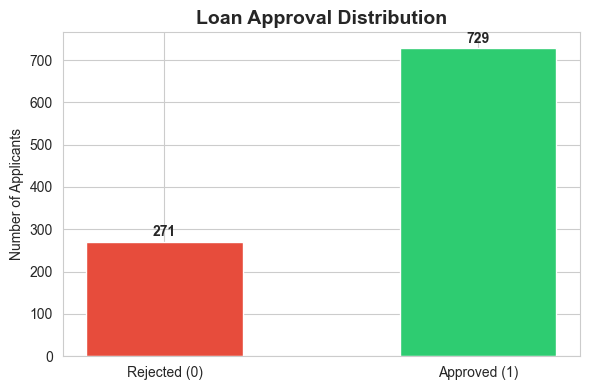


⚠️  Notice: There are almost 3x more approvals than rejections.
   This is called CLASS IMBALANCE — we will handle it with SMOTE later!


In [32]:
counts = df['loan_approved'].value_counts()
print("Class distribution:")
print(f"  Approved (1): {counts[1]} — {counts[1]/len(df)*100:.1f}%")
print(f"  Rejected (0): {counts[0]} — {counts[0]/len(df)*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Rejected (0)', 'Approved (1)'], [counts[0], counts[1]],
              color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold')
ax.set_title('Loan Approval Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Applicants')
plt.tight_layout()
plt.show()

print("\n⚠️  Notice: There are almost 3x more approvals than rejections.")
print("   This is called CLASS IMBALANCE — we will handle it with SMOTE later!")

### 4.2 Exploring Individual Features

Let's look at how each feature is distributed.

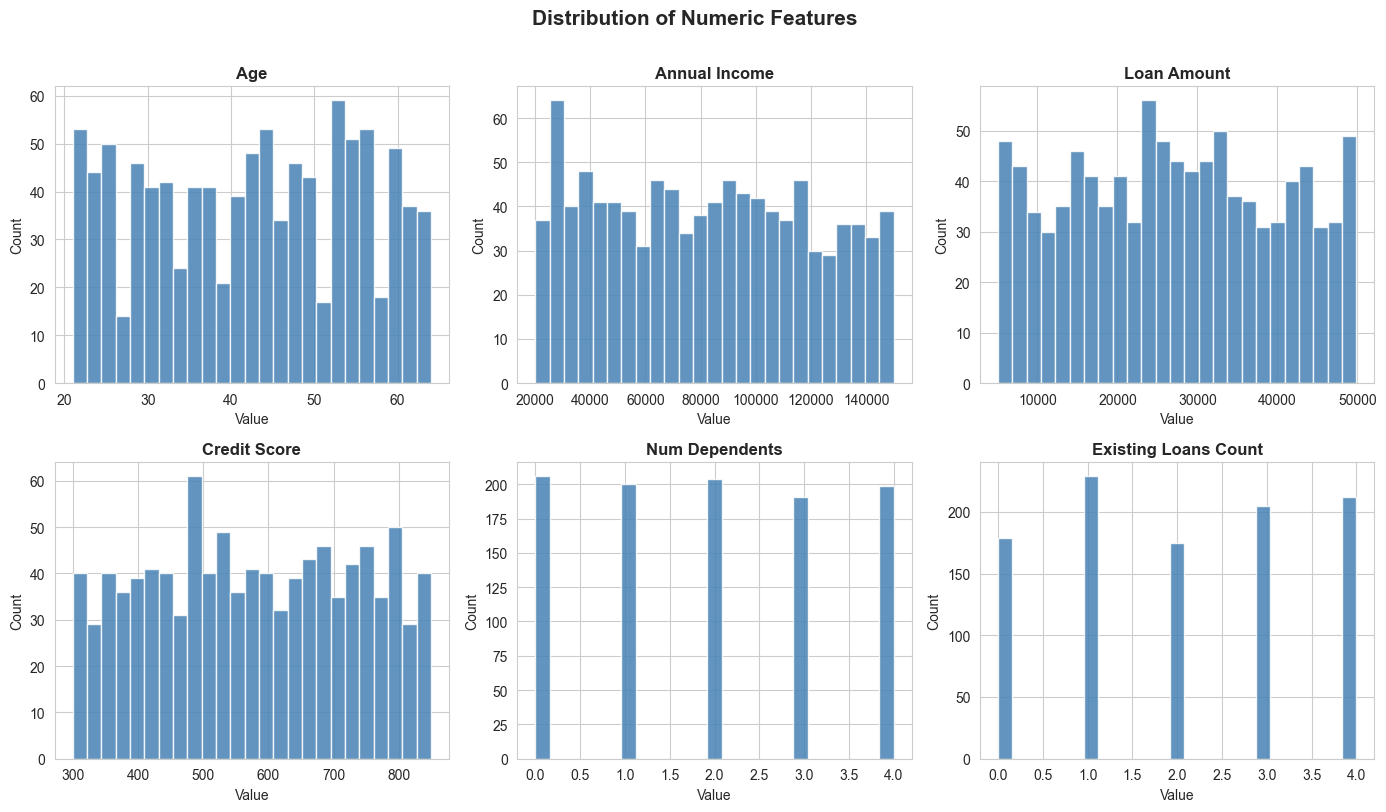

In [33]:
numeric_cols = ['age', 'annual_income', 'loan_amount',
                'credit_score', 'num_dependents', 'existing_loans_count']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Numeric Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

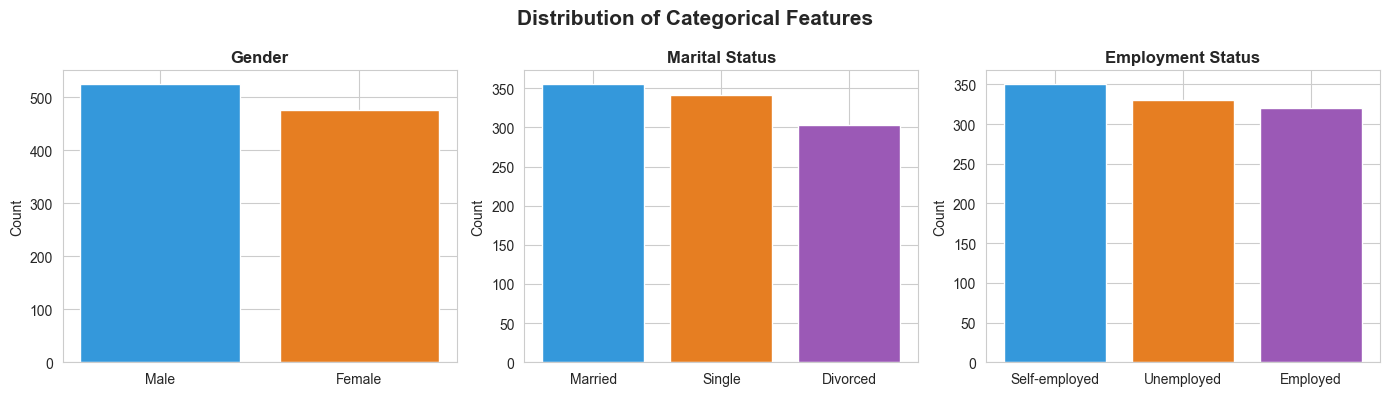

In [34]:
cat_cols = ['gender', 'marital_status', 'employment_status']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(cat_cols):
    counts_cat = df[col].value_counts()
    axes[i].bar(counts_cat.index, counts_cat.values,
                color=['#3498db','#e67e22','#9b59b6'], edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

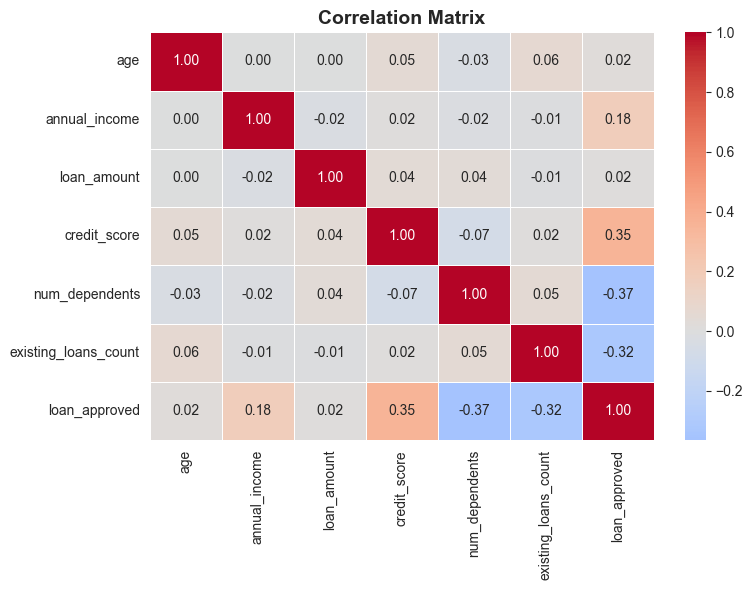

💡 Values close to +1 mean strong positive correlation.
   Values close to -1 mean strong negative correlation.
   Values close to 0 mean little to no correlation.


In [35]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + ['loan_approved']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 Values close to +1 mean strong positive correlation.")
print("   Values close to -1 mean strong negative correlation.")
print("   Values close to 0 mean little to no correlation.")

---
## 📌 Section 4.3: Scatter Plot — See Your Raw Data Before Training

Before we let the model train, let's **visualize the raw data** as a scatter plot.  
This helps us see whether the two classes (Approved / Rejected) are **naturally separable**.

We use **Credit Score** (x-axis) and **Annual Income** (y-axis) — both are strong predictors.

> 🟢 Green dots = Loan Approved  
> 🔴 Red dots = Loan Rejected

After looking at this plot, ask yourself:  
*"If I drew a line between the green and red dots, could I separate them?"*  
That is exactly what the model is learning to do!

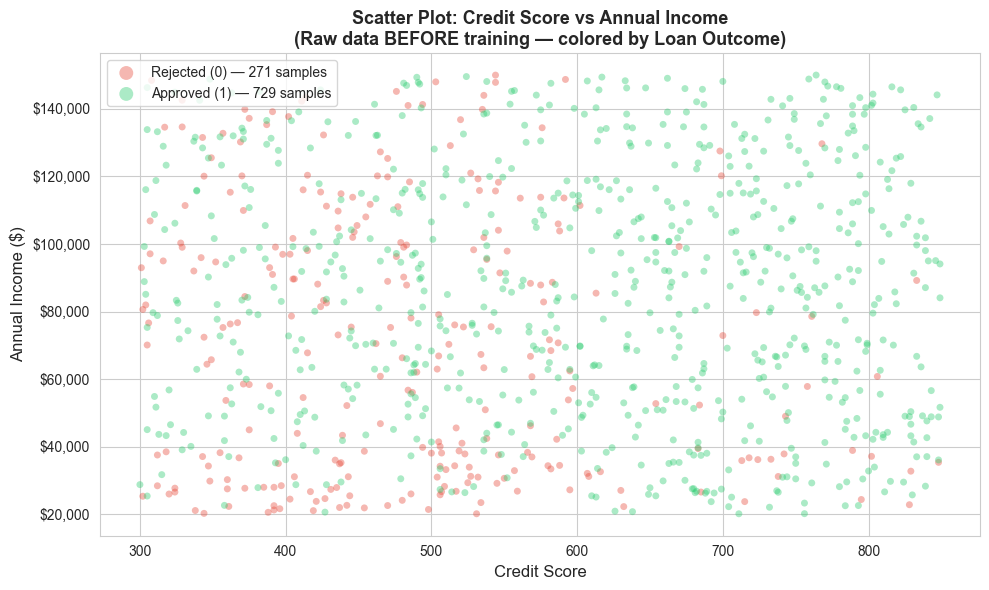

💡 What to notice:
   - High credit score + high income → mostly GREEN (Approved)
   - Low credit score + low income  → mostly RED (Rejected)
   - The messy overlap in the middle is where the model has to make hard decisions


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

approved = df[df['loan_approved'] == 1]
rejected = df[df['loan_approved'] == 0]

ax.scatter(rejected['credit_score'], rejected['annual_income'],
           c='#e74c3c', alpha=0.4, s=25, edgecolors='none',
           label=f'Rejected (0) — {len(rejected)} samples')

ax.scatter(approved['credit_score'], approved['annual_income'],
           c='#2ecc71', alpha=0.4, s=25, edgecolors='none',
           label=f'Approved (1) — {len(approved)} samples')

ax.set_xlabel('Credit Score', fontsize=12)
ax.set_ylabel('Annual Income ($)', fontsize=12)
ax.set_title(
    'Scatter Plot: Credit Score vs Annual Income\n'
    '(Raw data BEFORE training — colored by Loan Outcome)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10, markerscale=2)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print("💡 What to notice:")
print("   - High credit score + high income → mostly GREEN (Approved)")
print("   - Low credit score + low income  → mostly RED (Rejected)")
print("   - The messy overlap in the middle is where the model has to make hard decisions")

---
## 📈 Section 4.4: The Sigmoid Function — Visualized!

Remember the sigmoid formula?
```
Sigmoid(z) = 1 / (1 + e^(-z))
```

### What is `z`?
`z` is a weighted sum the model computes from your input features:
```
z = (w1 × credit_score) + (w2 × income) + (w3 × age) + ... + bias
```

- If z is **very large** (e.g., +10) → sigmoid outputs close to **1** → Approved
- If z is **very negative** (e.g., -10) → sigmoid outputs close to **0** → Rejected
- If z is **0** → sigmoid outputs exactly **0.5** → the decision boundary!

> 🎯 The sigmoid curve is the **heart** of logistic regression.
> No matter what z is, the output is always between 0 and 1 — a clean probability.

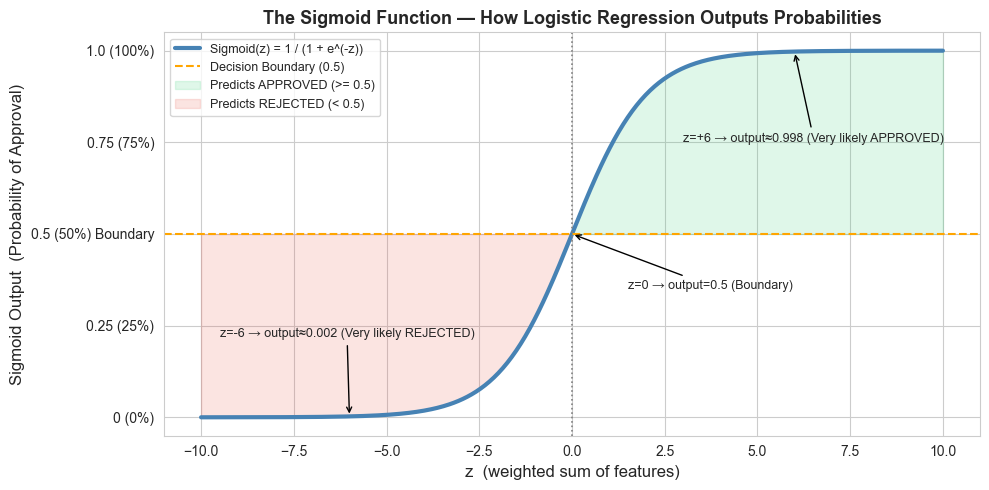

💡 Key takeaways:
   - No matter how extreme z is, the output is ALWAYS between 0 and 1
   - The S-shape is what makes it better than a straight line for classification


In [37]:
z = np.linspace(-10, 10, 500)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(z, sigmoid, color='steelblue', linewidth=3,
        label='Sigmoid(z) = 1 / (1 + e^(-z))')
ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.5,
           label='Decision Boundary (0.5)')
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.2)

ax.fill_between(z, 0.5, sigmoid, where=(sigmoid >= 0.5),
                alpha=0.15, color='#2ecc71', label='Predicts APPROVED (>= 0.5)')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5),
                alpha=0.15, color='#e74c3c', label='Predicts REJECTED (< 0.5)')

ax.annotate('z=0 → output=0.5 (Boundary)',
            xy=(0, 0.5), xytext=(1.5, 0.35),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.annotate('z=+6 → output≈0.998 (Very likely APPROVED)',
            xy=(6, 1/(1+np.exp(-6))), xytext=(3.0, 0.75),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.annotate('z=-6 → output≈0.002 (Very likely REJECTED)',
            xy=(-6, 1/(1+np.exp(6))), xytext=(-9.5, 0.22),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.set_xlabel('z  (weighted sum of features)', fontsize=12)
ax.set_ylabel('Sigmoid Output  (Probability of Approval)', fontsize=12)
ax.set_title('The Sigmoid Function — How Logistic Regression Outputs Probabilities',
             fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0 (0%)', '0.25 (25%)', '0.5 (50%) Boundary', '0.75 (75%)', '1.0 (100%)'])
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print("💡 Key takeaways:")
print("   - No matter how extreme z is, the output is ALWAYS between 0 and 1")
print("   - The S-shape is what makes it better than a straight line for classification")

---
## ⚖️ Section 4.5: What is SMOTE? (And What Does it Do to Your Data?)

This is one of the most important sections — **read carefully!**

---

### 🤔 The Problem: Class Imbalance

Remember the bar chart we made? There were roughly **3x more approvals than rejections**.  
This is called **class imbalance**.

Why is imbalance a problem?  
Imagine a student who only studies the approved cases.  
On the exam (test set), they keep predicting Approved for everything and still get 75% correct!  
But they failed to learn how to spot a rejection — which is just as important for a bank.

A biased model like this will:
- ✅ Predict Approved correctly most of the time
- ❌ Miss many actual Rejected cases (dangerous for a bank!)

---

### 💡 The Solution: SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE **creates new, synthetic (fake-but-realistic) samples** of the minority class (Rejected)  
so that both classes become balanced before training.

> **SMOTE is NOT just copying existing rejected rows.**  
> It creates **brand new rows** by blending existing ones together.

---

### 🔬 What Happens Behind the Scenes — Step by Step

**Step 1: Pick a minority sample**  
SMOTE picks one rejected applicant, for example:
```
Applicant A (Rejected): credit_score=520, income=30000
```

**Step 2: Find its K nearest neighbors**  
It looks at the 5 most similar rejected applicants:
```
Neighbor B (Rejected): credit_score=540, income=32000
```

**Step 3: Create a new synthetic point between them**  
Pick a random number t between 0 and 1 (say t=0.6), then:
```
New credit_score = 520 + 0.6 × (540 - 520) = 532
New income       = 30000 + 0.6 × (32000 - 30000) = 31200
```
This creates a new rejected applicant that does not exist in the original data but looks realistic.

**Step 4: Repeat until balanced**  
SMOTE keeps doing this until Rejected has as many rows as Approved.

---

### 📊 What Happens to Your Data?

| | Before SMOTE | After SMOTE |
|---|---|---|
| Approved | ~750 rows | ~750 rows (unchanged) |
| Rejected | ~250 rows | ~750 rows (synthetic added!) |
| Balance | ❌ Imbalanced | ✅ Balanced |

---

### ⚠️ Critical Rule: SMOTE on Training Data ONLY!

SMOTE is applied **only to the training set**, never the test set.  
The test set represents real unseen data — we evaluate on real examples, not synthetic ones.  
When we put SMOTE inside the Pipeline, this rule is automatically enforced. ✅

```
Training → preprocessor → SMOTE (adds synthetic rows) → model learns
Testing  → preprocessor → SMOTE SKIPPED              → model predicts
```

---

### Why Does SMOTE Come AFTER the Preprocessor?

SMOTE needs to work with **numbers**, not raw text like Male or Married.  
So we encode and scale first, then SMOTE creates synthetic rows from those numbers.  
Order matters: `ColumnTransformer → SMOTE → Model`

BEFORE SMOTE (original data):
  Approved (1): 729
  Rejected (0): 271
  Ratio: 2.7x more approvals

AFTER SMOTE (synthetic samples added):
  Approved (1): 729
  Rejected (0): 729
  Added 458 synthetic rejected samples


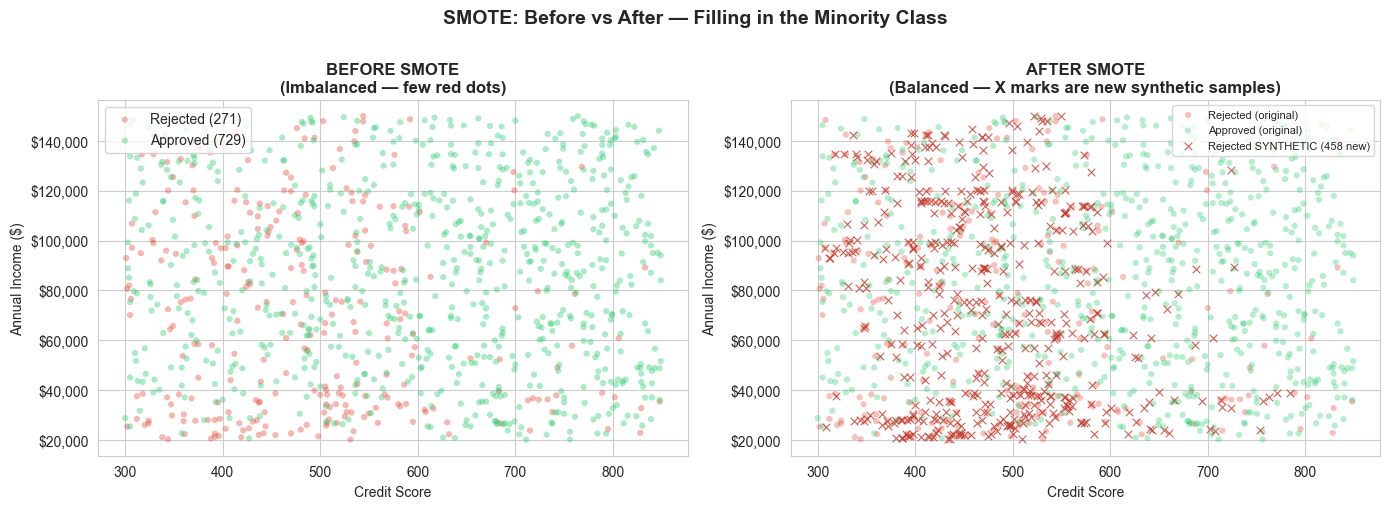


💡 The X marks are SYNTHETIC rejected applicants created by SMOTE.
   They are placed between real rejected applicants — blended, not copied.


In [38]:
from imblearn.over_sampling import SMOTE as SMOTEDemo

# Use 2 numeric features so we can plot in 2D
X_demo = df[['credit_score', 'annual_income']].values
y_demo = df['loan_approved'].values

unique, counts_before = np.unique(y_demo, return_counts=True)
print("BEFORE SMOTE (original data):")
print(f"  Approved (1): {counts_before[1]}")
print(f"  Rejected (0): {counts_before[0]}")
print(f"  Ratio: {counts_before[1]/counts_before[0]:.1f}x more approvals")

smote_demo = SMOTEDemo(random_state=42)
X_demo_res, y_demo_res = smote_demo.fit_resample(X_demo, y_demo)

unique2, counts_after = np.unique(y_demo_res, return_counts=True)
print("\nAFTER SMOTE (synthetic samples added):")
print(f"  Approved (1): {counts_after[1]}")
print(f"  Rejected (0): {counts_after[0]}")
print(f"  Added {counts_after[0] - counts_before[0]} synthetic rejected samples")

# Split original vs synthetic
n_orig = len(X_demo)
X_synth = X_demo_res[n_orig:]
y_synth = y_demo_res[n_orig:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
ax = axes[0]
for label, color, name in [(0, '#e74c3c', 'Rejected'), (1, '#2ecc71', 'Approved')]:
    mask = y_demo == label
    ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
               c=color, alpha=0.4, s=20, edgecolors='none', label=f'{name} ({mask.sum()})')
ax.set_title('BEFORE SMOTE\n(Imbalanced — few red dots)', fontsize=12, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Annual Income ($)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# After SMOTE
ax = axes[1]
for label, color, name in [(0, '#e74c3c', 'Rejected (original)'), (1, '#2ecc71', 'Approved (original)')]:
    mask = y_demo == label
    ax.scatter(X_demo[mask, 0], X_demo[mask, 1],
               c=color, alpha=0.35, s=20, edgecolors='none', label=name)
synth_rej = y_synth == 0
ax.scatter(X_synth[synth_rej, 0], X_synth[synth_rej, 1],
           c='#c0392b', alpha=0.8, s=30, marker='x', linewidths=0.8,
           label=f'Rejected SYNTHETIC ({synth_rej.sum()} new)')
ax.set_title('AFTER SMOTE\n(Balanced — X marks are new synthetic samples)', fontsize=12, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Annual Income ($)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('SMOTE: Before vs After — Filling in the Minority Class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 The X marks are SYNTHETIC rejected applicants created by SMOTE.")
print("   They are placed between real rejected applicants — blended, not copied.")

---
## 🔧 Section 5: Data Preprocessing with ColumnTransformer + Pipeline

### Our two column types:
| Column Type | Columns | Transformation |
|-------------|---------|----------------|
| **Numeric** | age, annual_income, loan_amount, credit_score, num_dependents, existing_loans_count | `StandardScaler` |
| **Categorical** | gender, marital_status, employment_status | `OneHotEncoder` |

### Why OneHotEncoder instead of LabelEncoder?
> **LabelEncoder** assigns numbers like 0, 1, 2. But this implies an order that does not exist!  
> **OneHotEncoder** creates a separate 0/1 column for each category — more mathematically honest.

### 5.1 Split Features (X) and Target (y), then Train/Test Split

- **X** = everything the model uses to make a prediction
- **y** = what we are predicting (loan_approved)
- **Train set (80%)** → model learns from this
- **Test set (20%)** → we check performance on unseen data

In [39]:
X = df.drop(columns=['loan_approved'])
y = df['loan_approved']



print(f"Features (X) shape: {X.shape}")
print(f"Target  (y) shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features (X) shape: (1000, 9)
Target  (y) shape: (1000,)

Feature columns: ['age', 'gender', 'marital_status', 'annual_income', 'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count', 'employment_status']


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Test set size:      {X_test.shape[0]} samples")
print("\nTraining class balance:")
print(y_train.value_counts())

Training set size:  800 samples
Test set size:      200 samples

Training class balance:
loan_approved
1    583
0    217
Name: count, dtype: int64


### 5.2 Build the ColumnTransformer

In [42]:
numeric_features     = ['age', 'annual_income', 'loan_amount',
                         'credit_score', 'num_dependents', 'existing_loans_count']
categorical_features = ['gender', 'marital_status', 'employment_status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

print("✅ ColumnTransformer built!")
print(f"  Numeric  → StandardScaler on: {numeric_features}")
print(f"  Categorical → OneHotEncoder on: {categorical_features}")

✅ ColumnTransformer built!
  Numeric  → StandardScaler on: ['age', 'annual_income', 'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count']
  Categorical → OneHotEncoder on: ['gender', 'marital_status', 'employment_status']


### 5.3 Build the Full Pipeline (with SMOTE inside!)

```
Pipeline steps:
  1. preprocessor  → ColumnTransformer (scale + encode)
  2. smote         → SMOTE (balance classes — training only!)
  3. classifier    → LogisticRegression
```

> ⚠️ SMOTE only runs during `.fit()` (training), **not** during `.predict()` (testing). The pipeline enforces this automatically!

In [43]:
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor), 
    ('smote',        SMOTE(random_state=42)),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

print("✅ Pipeline built! Steps:")
for name, obj in pipeline.steps:
    print(f"   {name}: {type(obj).__name__}")

✅ Pipeline built! Steps:
   preprocessor: ColumnTransformer
   smote: SMOTE
   classifier: LogisticRegression


---
## 🤖 Section 6: Train the Pipeline

This single `.fit()` call does **everything** automatically:

1. Fits the `StandardScaler` on training data and scales X_train
2. Fits the `OneHotEncoder` on training data and encodes X_train
3. Applies SMOTE to create synthetic rejected rows → balanced dataset
4. Trains the `LogisticRegression` model on the balanced data

**What happens during training?**  
The model looks at each row, makes a prediction, compares it to the real answer,  
and adjusts its internal weights to reduce the error. This repeats until it converges.

In [44]:
pipeline.fit(X_train, y_train)

print("✅ Pipeline trained successfully!")
trained_model = pipeline.named_steps['classifier']
print(f"\nModel converged in {trained_model.n_iter_[0]} iterations.")

✅ Pipeline trained successfully!

Model converged in 16 iterations.


### 6.1 View Model Coefficients

Each coefficient tells us how much each feature pushes the prediction.
- **Positive coefficient** → increases probability of approval
- **Negative coefficient** → decreases probability of approval

Model Coefficients:
                        Feature  Coefficient
                   credit_score     1.741549
                  annual_income     1.126815
employment_status_Self-employed     0.643426
         marital_status_Married     0.346963
                    gender_Male     0.211207
          marital_status_Single     0.203028
                    loan_amount     0.051984
                            age     0.014562
           existing_loans_count    -1.797112
                 num_dependents    -2.014074
   employment_status_Unemployed    -3.574617


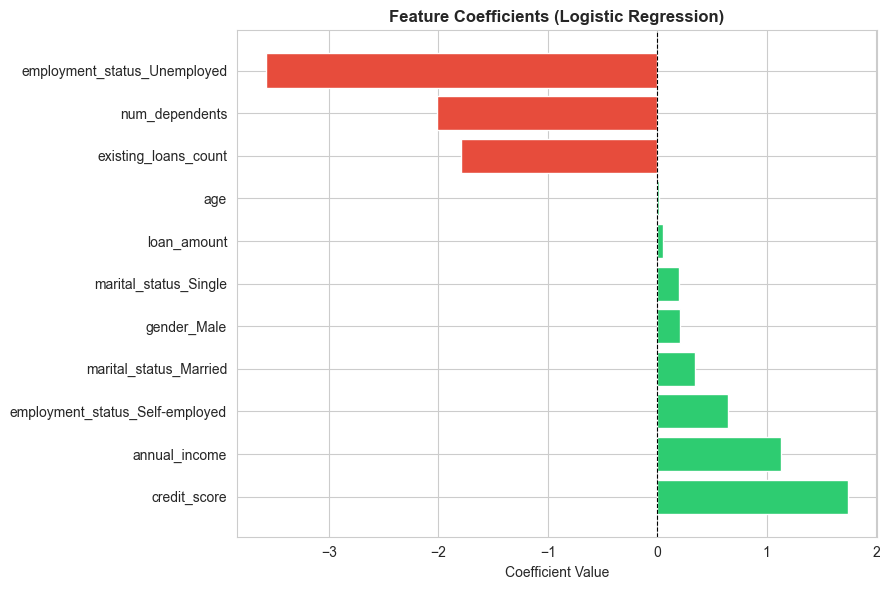


💡 Green = pushes toward Approved | Red = pushes toward Rejected


In [ ]:
ohe_names = (pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features).tolist())
all_names = numeric_features + ohe_names

coef_df = pd.DataFrame({
    'Feature':     all_names,
    'Coefficient': trained_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients:")
print(coef_df.to_string(index=False))



plt.figure(figsize=(9, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Coefficients (Logistic Regression)', fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\n💡 Green = pushes toward Approved | Red = pushes toward Rejected")

---
## 🗺️ Section 6.2: Decision Boundary — Where Does the Model Draw the Line?

After training, the model has learned a **decision boundary** — an invisible line that separates:
- Applicants predicted as **APPROVED** (one side)
- Applicants predicted as **REJECTED** (other side)

For logistic regression, this boundary is **always a straight line** in 2D — because logistic regression is a *linear* model.

### How to read this plot:
- 🟢 Green background region → model predicts **APPROVED** here
- 🔴 Red background region → model predicts **REJECTED** here
- The **white dashed line** in the middle = the decision boundary (probability = 0.5)
- Dots are the **actual data points** colored by their **true label**
- A dot in the **wrong color zone** = the model made a mistake on that point

> 💡 We use only 2 features (credit_score + annual_income) to draw this in 2D.  
> The real model uses ALL features — its boundary lives in higher dimensions,  
> but the concept is exactly the same!

In [ ]:
# from sklearn.preprocessing import StandardScaler as SS
# from sklearn.linear_model import LogisticRegression as LR

# # 2-feature data for visualization only
# X_2d = df[['credit_score', 'annual_income']].values
# y_2d = df['loan_approved'].values

# # Scale
# scaler_2d = SS()
# X_2d_scaled = scaler_2d.fit_transform(X_2d)

# # Apply SMOTE on the 2D scaled data
# smote_2d = SMOTE(random_state=42)
# X_2d_res, y_2d_res = smote_2d.fit_resample(X_2d_scaled, y_2d)

# # Train a 2D logistic regression
# clf_2d = LR(random_state=42, max_iter=1000)
# clf_2d.fit(X_2d_res, y_2d_res)

# # Create mesh grid
# h = 0.02
# x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
# y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
# xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# # Predict probability at every grid point
# Z = clf_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

# fig, ax = plt.subplots(figsize=(11, 7))

# # Background heatmap
# cf = ax.contourf(xx, yy, Z, levels=50, cmap='RdYlGn', alpha=0.4, vmin=0, vmax=1)

# # Decision boundary line
# ax.contour(xx, yy, Z, levels=[0.5], colors='white', linewidths=2.5, linestyles='--')

# # Colorbar
# cbar = plt.colorbar(cf, ax=ax, shrink=0.8)
# cbar.set_label('Predicted Probability of Approval', fontsize=10)

# # Scatter actual data
# for label, color, marker, name in [
#     (0, '#c0392b', 'o', 'Rejected (actual)'),
#     (1, '#1a7a4a', '^', 'Approved (actual)')
# ]:
#     mask = y_2d == label
#     ax.scatter(X_2d_scaled[mask, 0], X_2d_scaled[mask, 1],
#                c=color, marker=marker, s=20, alpha=0.5, edgecolors='none', label=name)

# ax.text(0.02, 0.97,
#         'White dashed line = Decision Boundary (P=0.5)\n'
#         'Left of line → predicted REJECTED\n'
#         'Right of line → predicted APPROVED',
#         transform=ax.transAxes, fontsize=8.5, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ax.set_xlabel('Credit Score (scaled)', fontsize=12)
# ax.set_ylabel('Annual Income (scaled)', fontsize=12)
# ax.set_title(
#     'Decision Boundary — Where the Model Draws the Line\n'
#     '(2D visualization using Credit Score & Annual Income only)',
#     fontsize=13, fontweight='bold'
# )
# ax.legend(fontsize=10, loc='lower right')
# plt.tight_layout()
# plt.show()

# print("💡 The boundary is a STRAIGHT LINE — logistic regression is a linear model")
# print("   Dots in the wrong color zone = model mistakes")
# print("   The overlap region in the middle is where most errors occur")

---
## 📊 Section 7: Model Evaluation

We evaluate on the **test set** — data the model has never seen before.

| Metric | What it means |
|--------|---------------|
| **Accuracy** | Overall % of correct predictions |
| **Precision** | When model says Approved, how often is it right? |
| **Recall** | Of all actual approvals, how many did the model catch? |
| **F1 Score** | Balance between precision and recall |
| **AUC-ROC** | 0.5 = random guessing, 1.0 = perfect model |

For imbalanced problems, **F1 Score and AUC-ROC are more meaningful than accuracy**.

In [46]:
y_pred       = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {acc:.4f} ({acc*100:.1f}%)")
print(f"AUC-ROC  : {auc:.4f}")

Accuracy : 0.8750 (87.5%)
AUC-ROC  : 0.9508


In [47]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Rejected (0)', 'Approved (1)']))

=== Classification Report ===
              precision    recall  f1-score   support

Rejected (0)       0.74      0.83      0.78        54
Approved (1)       0.94      0.89      0.91       146

    accuracy                           0.88       200
   macro avg       0.84      0.86      0.85       200
weighted avg       0.88      0.88      0.88       200



### 7.1 Confusion Matrix

```
                    Predicted Rejected | Predicted Approved
Actual Rejected  |   True Negative (TN) |  False Positive (FP)
Actual Approved  |  False Negative (FN) |   True Positive (TP)
```

- **TN** = Correctly predicted rejection ✅
- **TP** = Correctly predicted approval ✅
- **FP** = Predicted approval but was actually rejected ❌
- **FN** = Predicted rejection but was actually approved ❌

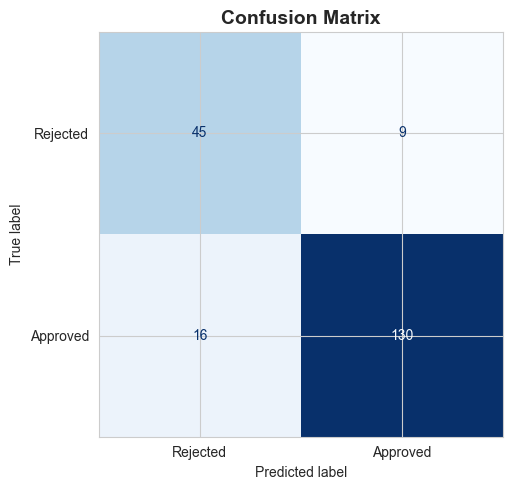

True Negatives  (Correctly rejected): 45
True Positives  (Correctly approved): 130
False Positives (Wrongly approved):   9
False Negatives (Wrongly rejected):   16


In [48]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly rejected): {tn}")
print(f"True Positives  (Correctly approved): {tp}")
print(f"False Positives (Wrongly approved):   {fp}")
print(f"False Negatives (Wrongly rejected):   {fn}")

### 7.2 ROC Curve

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.  
A model guessing randomly follows the diagonal line (AUC = 0.5).  
A better model curves toward the top-left (AUC closer to 1.0).

In [ ]:
# fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
# plt.figure(figsize=(7, 5))
# plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
# plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
# plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate (Recall)')
# plt.title('ROC Curve', fontsize=14, fontweight='bold')
# plt.legend(loc='lower right')
# plt.tight_layout()
# plt.show()

### 7.3 Predict for a New Applicant

This is where Pipeline truly shines!  
We pass in **raw data** (no encoding, no scaling needed) and the pipeline handles everything.

In [49]:
print("=== Predict for a New Applicant ===\n")

new_applicant = pd.DataFrame({
    'age':                  [35],
    'gender':               ['Male'],
    'marital_status':       ['Married'],
    'annual_income':        [60000],
    'loan_amount':          [20000],
    'credit_score':         [720],
    'num_dependents':       [2],
    'existing_loans_count': [1],
    'employment_status':    ['Employed']
})

prediction  = pipeline.predict(new_applicant)[0]
probability = pipeline.predict_proba(new_applicant)[0][1]

print("Applicant: Age 35, Married Male, Income $60k, Credit Score 720")
print(f"Prediction  : {'✅ APPROVED' if prediction == 1 else '❌ REJECTED'}")
print(f"Probability : {probability:.2%} chance of approval")
print("\n💡 We passed raw strings like Male, Married — the pipeline encoded them automatically!")

=== Predict for a New Applicant ===

Applicant: Age 35, Married Male, Income $60k, Credit Score 720
Prediction  : ✅ APPROVED
Probability : 99.53% chance of approval

💡 We passed raw strings like Male, Married — the pipeline encoded them automatically!


---
## 💾 Section 8: Save the Pipeline

The best part of using a Pipeline: **we only save one file!**

```
❌ Old way: save model.pkl + scaler.pkl separately
✅ Pipeline: save pipeline.pkl — one file contains everything!
```

In [ ]:
joblib.dump(pipeline, 'loan_pipeline.pkl')
print("✅ Pipeline saved → loan_pipeline.pkl")
print("   Contains: ColumnTransformer + SMOTE + LogisticRegression")  

In [ ]:
loaded_pipeline = joblib.load('loan_pipeline.pkl')
reloaded_pred = loaded_pipeline.predict(new_applicant)[0]
print(f"Prediction using loaded pipeline: {'✅ APPROVED' if reloaded_pred == 1 else '❌ REJECTED'}")
print("\n✅ Pipeline loads and predicts correctly — raw data in, prediction out!")

---
## 🎓 Section 9: Summary — What Did We Do?

Congratulations! 🎉 Here is the full ML workflow we followed:

| Step | What we did |
|------|-------------|
| **1. Algorithm** | Learned what Logistic Regression is and why it works for classification |
| **2. Pipeline** | Learned what ColumnTransformer and Pipeline are |
| **3. Load data** | Read `loanapproval.csv` into a DataFrame |
| **4. EDA** | Checked distributions, missing values, correlations |
| **4.3 Scatter Plot** | 🆕 Visualized raw data BEFORE training |
| **4.4 Sigmoid** | 🆕 Plotted the sigmoid function — heart of logistic regression |
| **4.5 SMOTE** | 🆕 Explained + visualized what SMOTE does to your data |
| **5. Build Pipeline** | ColumnTransformer → SMOTE → LogisticRegression |
| **6. Train** | Called `pipeline.fit()` — one line does everything |
| **6.2 Boundary** | 🆕 Visualized the decision boundary after training |
| **7. Evaluate** | Accuracy, F1, Confusion Matrix, ROC-AUC |
| **8. Save** | Saved entire pipeline as one `.pkl` file |

### Key Takeaways
- **SMOTE** creates synthetic minority samples by blending neighbors — not copying!
- SMOTE must come AFTER encoding/scaling (needs numbers, not text)
- SMOTE only runs during `.fit()` — the pipeline enforces this automatically
- The **sigmoid function** outputs a probability between 0 and 1 — always
- The **decision boundary** is where probability = 0.5 — always a straight line for logistic regression
- Use F1 and AUC-ROC for imbalanced datasets, not just accuracy
- Save the whole pipeline — one file, raw data in, prediction out!

### Next Steps
- Try different `C` values in `LogisticRegression(C=...)` — this controls regularization
- Compare with Decision Tree, Random Forest, or SVM
- Try `cross_val_score(pipeline, X, y, cv=5)` — works directly with pipelines!
- Try `GridSearchCV(pipeline, param_grid)` for hyperparameter tuning